In [60]:
import numpy as np
import pandas as pd
import seaborn as sns

In [61]:
dataset = pd.read_csv('../dataset/Crime_Data_from_2020_to_Present.csv')
dataset.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,5/10/2023 0:00,3/10/2020 0:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,9/9/2020 0:00,9/9/2020 0:00,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130


In [62]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1005198 entries, 0 to 1005197
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1005198 non-null  int64  
 1   Date Rptd       1005198 non-null  str    
 2   DATE OCC        1005198 non-null  str    
 3   TIME OCC        1005198 non-null  int64  
 4   AREA            1005198 non-null  int64  
 5   AREA NAME       1005198 non-null  str    
 6   Rpt Dist No     1005198 non-null  int64  
 7   Part 1-2        1005198 non-null  int64  
 8   Crm Cd          1005198 non-null  int64  
 9   Crm Cd Desc     1005198 non-null  str    
 10  Mocodes         853438 non-null   str    
 11  Vict Age        1005198 non-null  int64  
 12  Vict Sex        860416 non-null   str    
 13  Vict Descent    860404 non-null   str    
 14  Premis Cd       1005182 non-null  float64
 15  Premis Desc     1004610 non-null  str    
 16  Weapon Used Cd  327280 non-null   float64
 17  

<Axes: xlabel='Vict Age', ylabel='Count'>

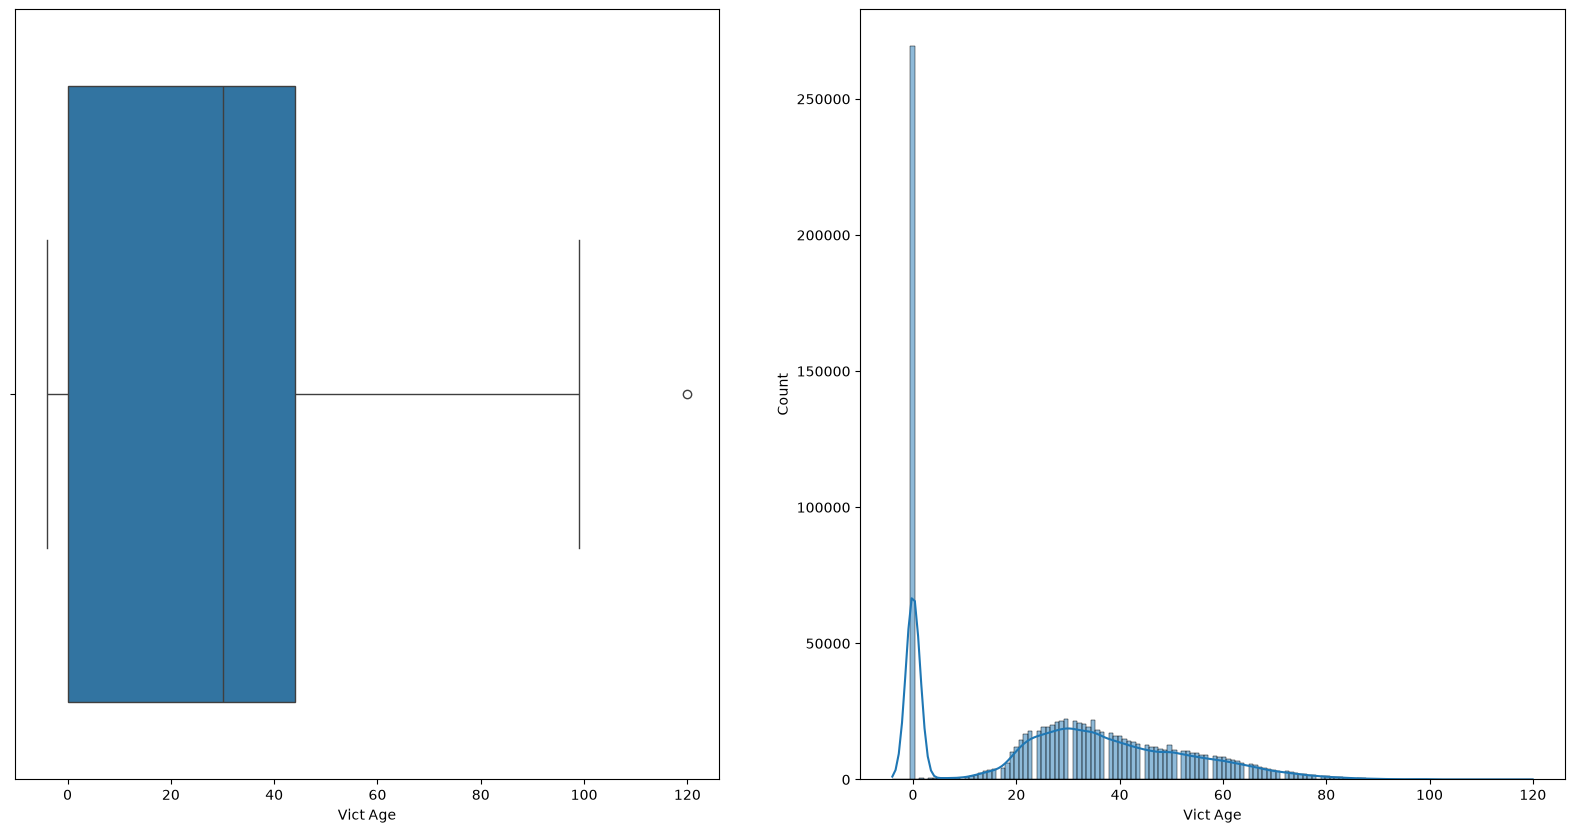

In [63]:
# outliers test 
import matplotlib.pyplot as plt
import seaborn as sns
figure , axes = plt.subplots(1,2,figsize=(20,10))
sns.boxplot(data = dataset ,x ='Vict Age' , ax = axes[0])
sns.histplot(data = dataset ,x ='Vict Age' , kde=True , ax = axes[1])

In [64]:
dataset.shape

(1005198, 28)

In [65]:
dataset = dataset[(dataset['Vict Age']>=0) & (dataset['Vict Age'] <=90)]
dataset.shape

(1003734, 28)

In [66]:
dataset['Vict Age'] = dataset['Vict Age'].replace(0 , np.nan)

In [67]:
dataset.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,5/10/2023 0:00,3/10/2020 0:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,9/9/2020 0:00,9/9/2020 0:00,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130


In [68]:
area_df = dataset.groupby('AREA NAME').agg({
    'DR_NO': 'count',
    'Vict Age': 'mean',
    'Premis Cd': 'nunique',
    'Crm Cd': 'nunique'
}).rename(columns={
    'DR_NO': 'Crime_Count',
    'Premis Cd': 'Unique_Premises',
    'Crm Cd': 'Unique_Crime_Types'

})

In [69]:
area_df

,Crime_Count,Vict Age,Unique_Premises,Unique_Crime_Types
AREA NAME,,,,
77th Street,61695,38.481278,171,119
Central,69599,37.938391,222,118
Devonshire,41645,42.318330,190,111
Foothill,33094,40.274744,168,109
Harbor,41421,40.516590,193,116
Hollenbeck,37031,39.272606,169,111
Hollywood,52388,37.818733,186,116
Mission,40326,38.908874,171,113
N Hollywood,51039,40.222524,194,121


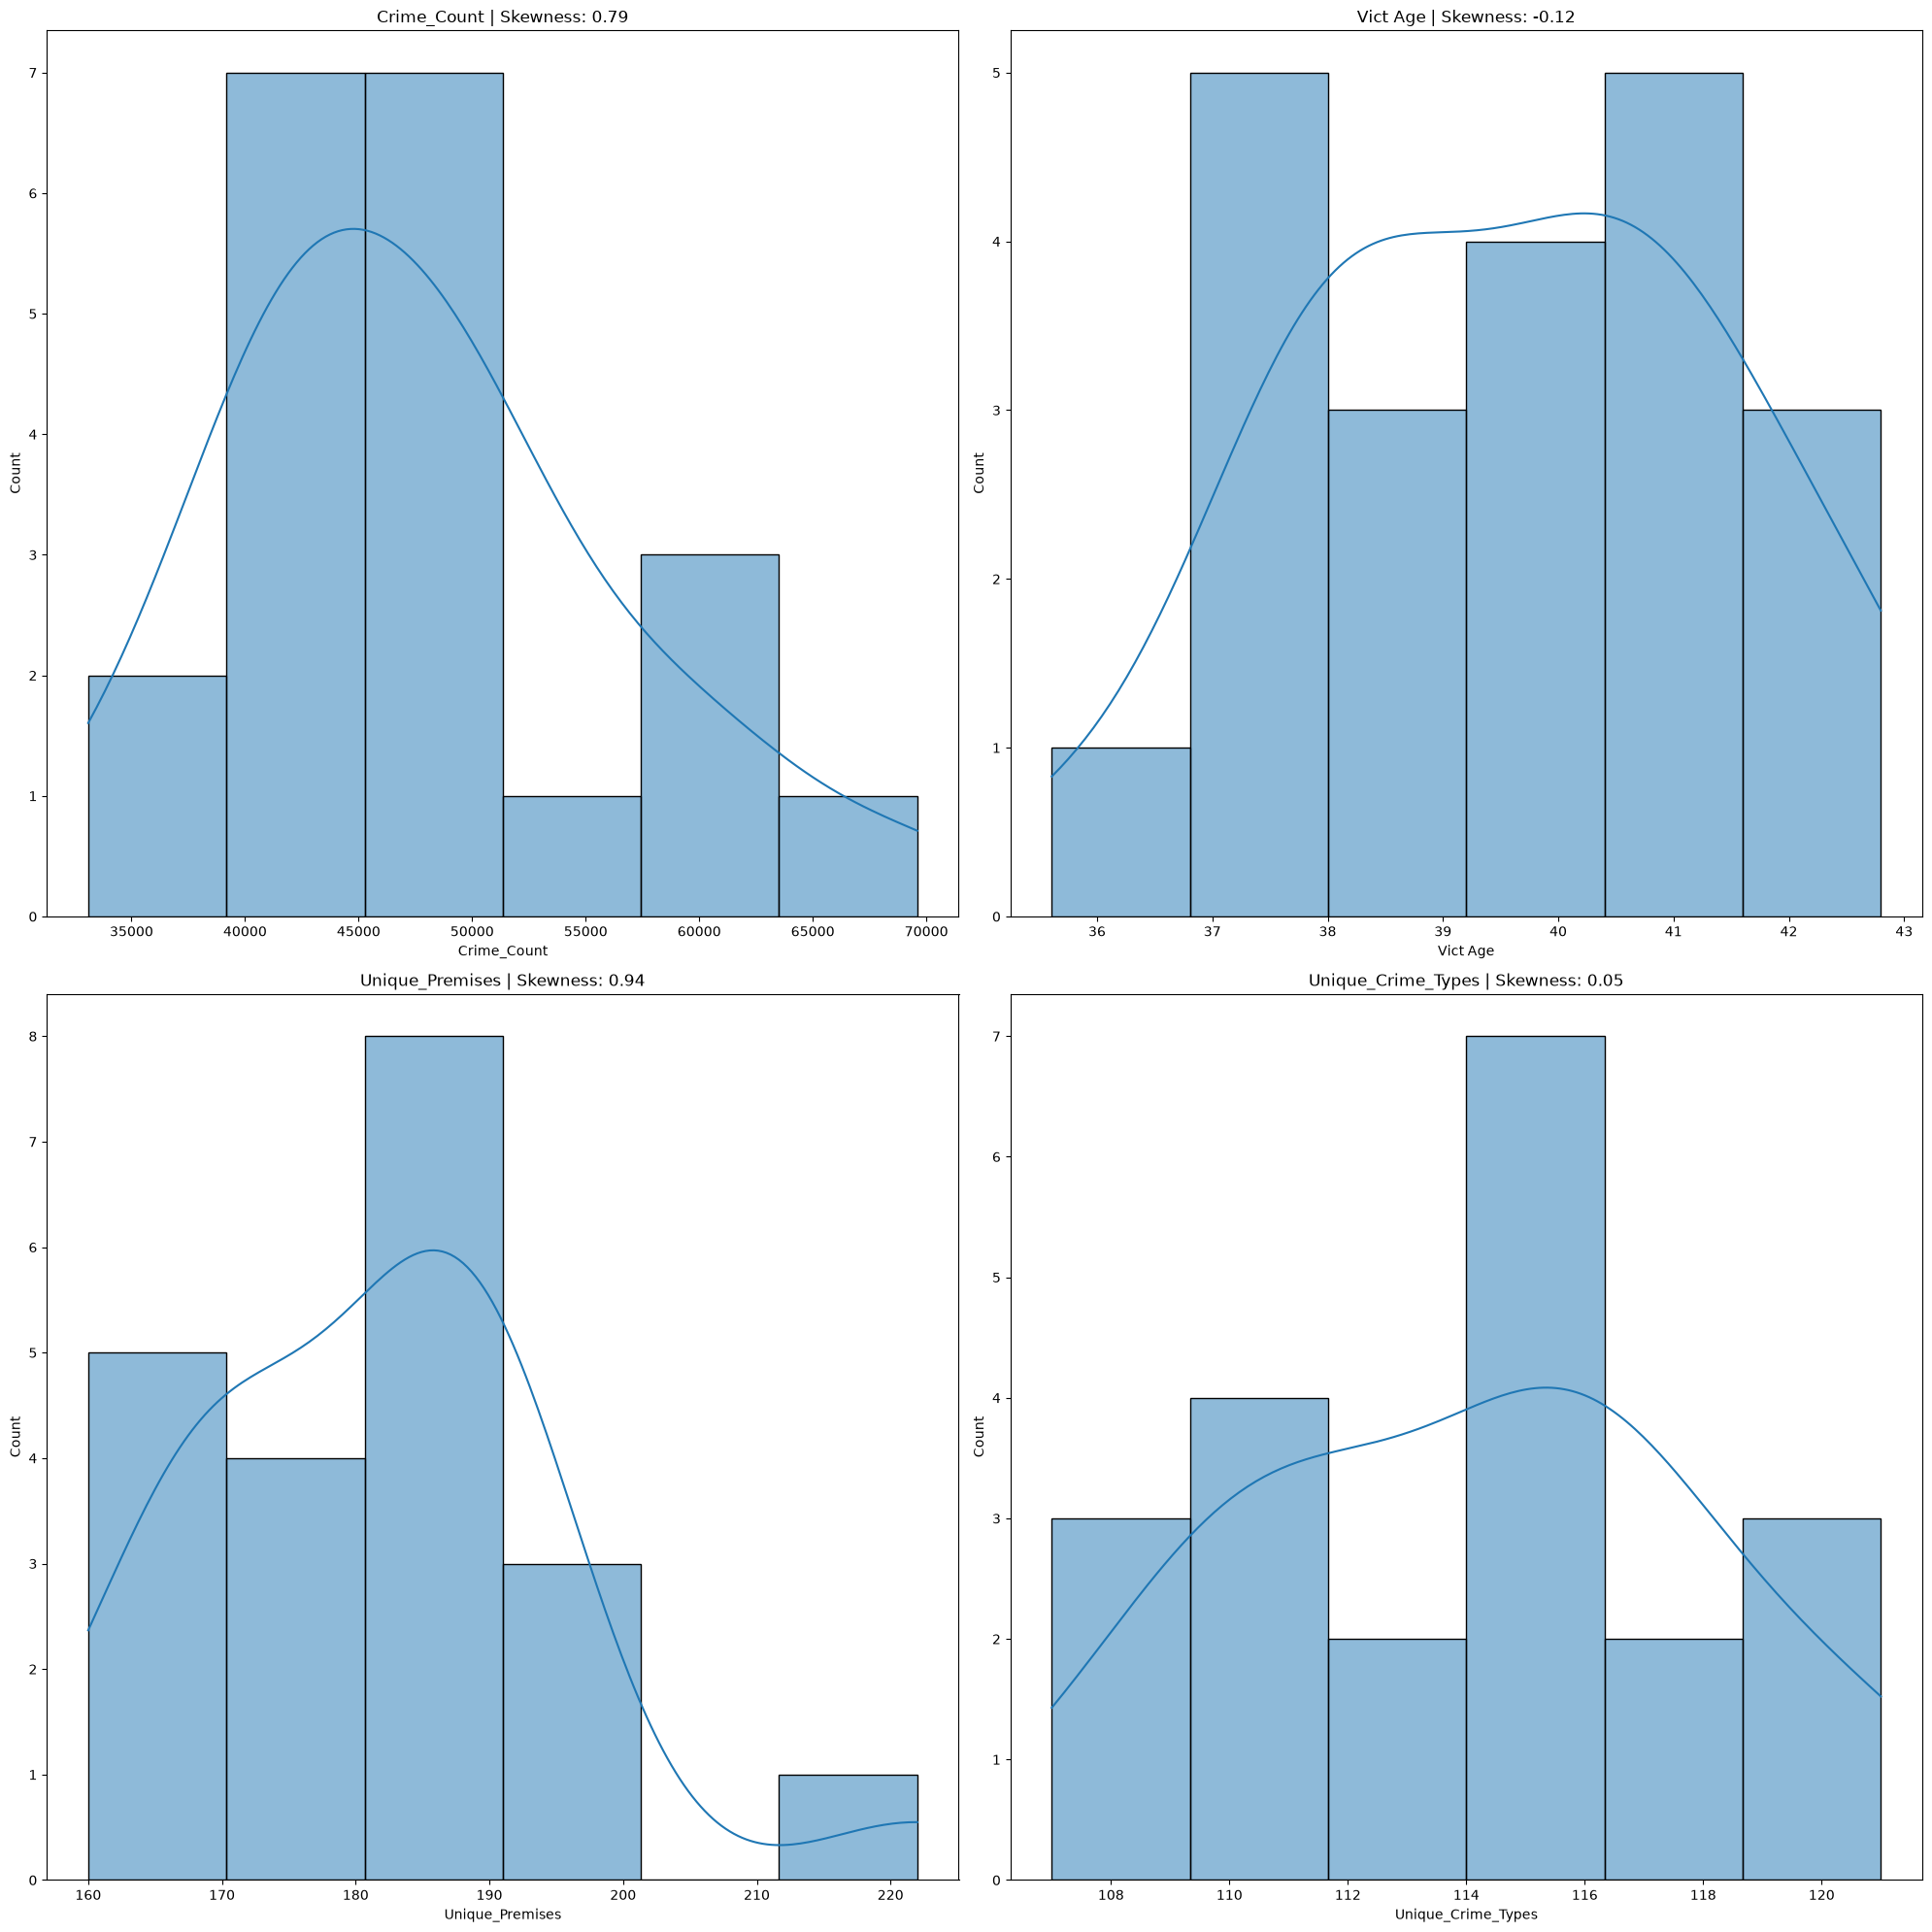

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(area_df.columns[:4]):  # ensure only 4 columns
    sns.histplot(
        data=area_df,
        x=col,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{col} | Skewness: {area_df[col].skew():.2f}"
    )

plt.tight_layout()
plt.show()

In [70]:
# Log transformation for the Unique Premises column
area_df['Unique_Premises_transformed'] = area_df['Unique_Premises'].apply(np.log1p)
area_df['Unique_Premises_transformed'].skew()

np.float64(0.65220506952512)

In [71]:
# Log transformation for the Unique Premises column
area_df['Crime_Count_transformed'] = area_df['Crime_Count'].apply(np.log1p)
area_df['Crime_Count_transformed'].skew()

np.float64(0.31398796521531197)

In [73]:
area_df.describe()

,Crime_Count,Vict Age,Unique_Premises,Unique_Crime_Types,Unique_Premises_transformed,Crime_Count_transformed
count,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000
mean,47796.857143,39.589657,181.857143,114.142857,5.206066,10.759421
std,8763.303443,1.906611,13.839385,3.953299,0.073901,0.177892
min,33094.000000,35.607441,160.000000,107.000000,5.081404,10.407137
25%,41645.000000,37.938391,171.000000,111.000000,5.147494,10.636961
50%,46778.000000,39.676504,183.000000,115.000000,5.214936,10.753190
75%,51039.000000,40.935950,189.000000,116.000000,5.247024,10.840365
max,69599.000000,42.797862,222.000000,121.000000,5.407172,11.150520


In [74]:
area_df

,Crime_Count,Vict Age,Unique_Premises,Unique_Crime_Types,Unique_Premises_transformed,Crime_Count_transformed
AREA NAME,,,,,,
77th Street,61695,38.481278,171,119,5.147494,11.029974
Central,69599,37.938391,222,118,5.407172,11.150520
Devonshire,41645,42.318330,190,111,5.252273,10.636961
Foothill,33094,40.274744,168,109,5.129899,10.407137
Harbor,41421,40.516590,193,116,5.267858,10.631567
Hollenbeck,37031,39.272606,169,111,5.135798,10.519538
Hollywood,52388,37.818733,186,116,5.231109,10.866452
Mission,40326,38.908874,171,113,5.147494,10.604776
N Hollywood,51039,40.222524,194,121,5.273000,10.840365


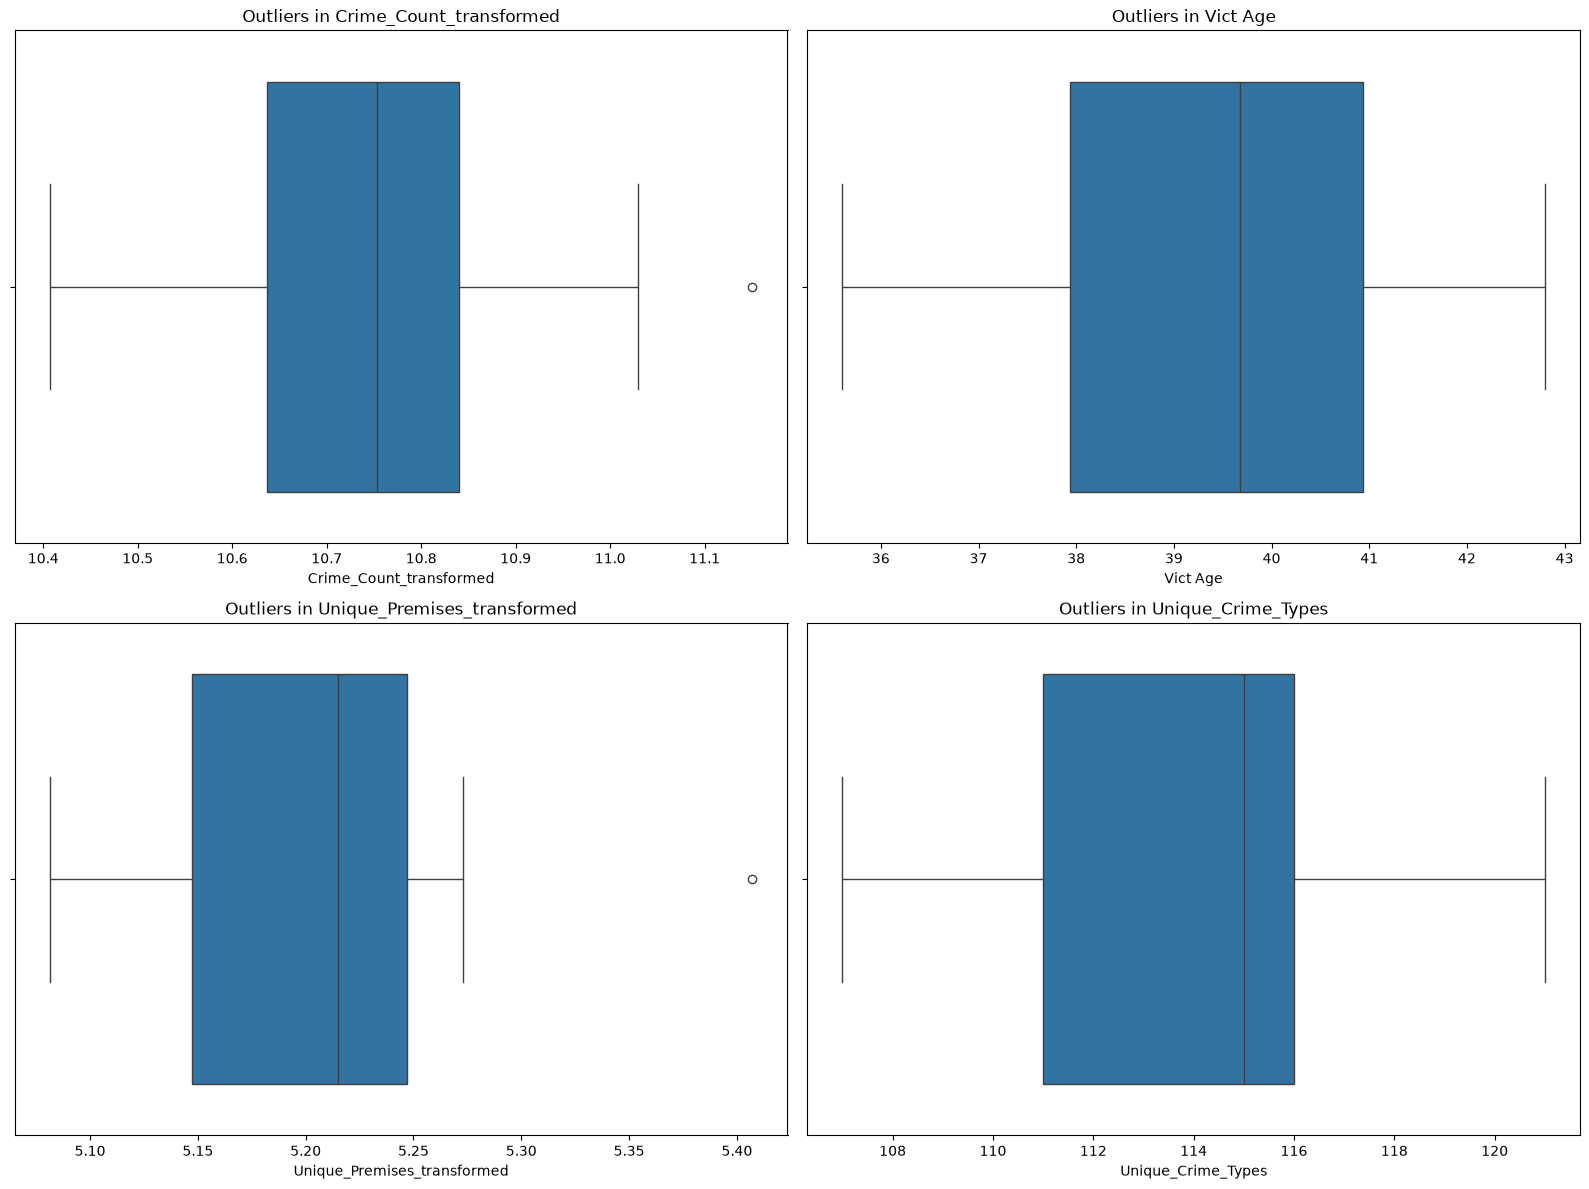

In [77]:
# checking for Outliers 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

cols = ['Crime_Count_transformed', 'Vict Age', 'Unique_Premises_transformed', 'Unique_Crime_Types']

for i, col in enumerate(cols):
    sns.boxplot(data=area_df, x=col, ax=axes[i])
    axes[i].set_title(f"Outliers in {col}")

plt.tight_layout()
plt.show()

In [79]:
# Dealing with the Outliers Explicitly
def calculate_iqr(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

_ , crime_Count_upper  = calculate_iqr(area_df['Crime_Count'])
crime_Count_upper

np.float64(65130.0)

In [80]:
crime_Count_outlier = area_df[area_df['Crime_Count'] > crime_Count_upper]
crime_Count_outlier

,Crime_Count,Vict Age,Unique_Premises,Unique_Crime_Types,Unique_Premises_transformed,Crime_Count_transformed
AREA NAME,,,,,,
Central,69599,37.938391,222,118,5.407172,11.15052


In [81]:
_ , Unique_premise_upper  = calculate_iqr(area_df['Unique_Premises'])
Unique_premise_upper

np.float64(216.0)

In [82]:
unique_premise_outlier = area_df[area_df['Unique_Premises'] > Unique_premise_upper]
unique_premise_outlier

,Crime_Count,Vict Age,Unique_Premises,Unique_Crime_Types,Unique_Premises_transformed,Crime_Count_transformed
AREA NAME,,,,,,
Central,69599,37.938391,222,118,5.407172,11.15052


In [83]:
outlier_idx = unique_premise_outlier.index.union(crime_Count_outlier.index)
outlier = area_df.loc[outlier_idx]

In [84]:
outlier

,Crime_Count,Vict Age,Unique_Premises,Unique_Crime_Types,Unique_Premises_transformed,Crime_Count_transformed
AREA NAME,,,,,,
Central,69599,37.938391,222,118,5.407172,11.15052


In [85]:
outlier['Cluster_label'] = -1
outlier['CLUSTER DESC'] = 'MULTI-LOCATION EXTREME CRIME HOTSPOT'
outlier

,Crime_Count,Vict Age,Unique_Premises,Unique_Crime_Types,Unique_Premises_transformed,Crime_Count_transformed,Cluster_label,CLUSTER DESC
AREA NAME,,,,,,,,
Central,69599,37.938391,222,118,5.407172,11.15052,-1,MULTI-LOCATION EXTREME CRIME HOTSPOT


In [86]:
non_outlier = area_df.drop(outlier.index)

In [87]:
non_outlier.shape

(20, 6)

In [88]:
non_outlier

,Crime_Count,Vict Age,Unique_Premises,Unique_Crime_Types,Unique_Premises_transformed,Crime_Count_transformed
AREA NAME,,,,,,
77th Street,61695,38.481278,171,119,5.147494,11.029974
Devonshire,41645,42.318330,190,111,5.252273,10.636961
Foothill,33094,40.274744,168,109,5.129899,10.407137
Harbor,41421,40.516590,193,116,5.267858,10.631567
Hollenbeck,37031,39.272606,169,111,5.135798,10.519538
Hollywood,52388,37.818733,186,116,5.231109,10.866452
Mission,40326,38.908874,171,113,5.147494,10.604776
N Hollywood,51039,40.222524,194,121,5.273000,10.840365
Newton,49140,37.240289,186,116,5.231109,10.802449


In [89]:
# Since we are dealing with the Lesser Area we can consider the Euclidean Transformation for the Non euclid geometric features

# declaration of the Features
features = non_outlier.drop(columns=['Crime_Count' ,'Unique_Premises'])
# such that
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [94]:
scaled_df = pd.DataFrame(scaled_features , columns=features.columns , index=features.index)

In [95]:
scaled_df

,Vict Age,Unique_Crime_Types,Unique_Premises_transformed,Crime_Count_transformed
AREA NAME,,,,
77th Street,-0.637313,1.310584,-0.839728,1.887831
Devonshire,1.416021,-0.765588,0.973810,-0.669644
Foothill,0.322430,-1.284631,-1.144280,-2.165181
Harbor,0.451850,0.532019,1.243555,-0.704739
Hollenbeck,-0.213847,-0.765588,-1.042166,-1.433754
Hollywood,-0.991863,0.532019,0.607485,0.823734
Mission,-0.408492,-0.246545,-0.839728,-0.879076
N Hollywood,0.294486,1.829627,1.332543,0.653977
Newton,-1.301407,0.532019,0.607485,0.407246


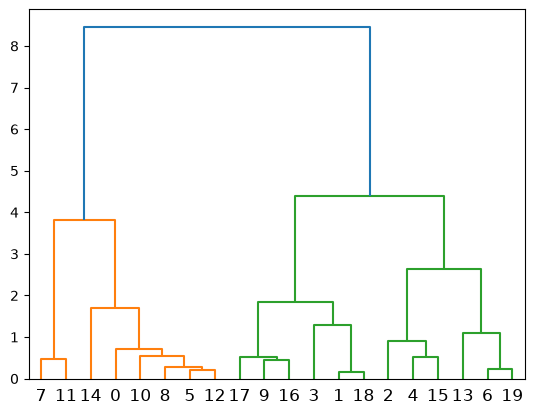

In [96]:
from scipy.cluster.hierarchy import dendrogram , linkage
from sklearn.decomposition import PCA

decomposer = PCA(n_components=2)
reduced_df = decomposer.fit_transform(scaled_df)
link = linkage(reduced_df , method='ward')
dendrogram(link);

In [97]:
from sklearn.cluster import AgglomerativeClustering
agg_cluster = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

In [98]:
labels = agg_cluster.fit_predict(reduced_df)

In [99]:
labels

array([1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0])

In [35]:
# Cluster Validation
from sklearn.metrics import silhouette_score , davies_bouldin_score
print(silhouette_score(reduced_df , labels))
print(davies_bouldin_score(reduced_df, labels))

0.426655868732002
0.8261637326920249


#### Consider the Metrices

In [103]:
non_outlier['Cluster_label'] = labels
non_outlier

,Crime_Count,Vict Age,Unique_Premises,Unique_Crime_Types,Unique_Premises_transformed,Crime_Count_transformed,Cluster_label
AREA NAME,,,,,,,
77th Street,61695,38.481278,171,119,5.147494,11.029974,1
Devonshire,41645,42.318330,190,111,5.252273,10.636961,0
Foothill,33094,40.274744,168,109,5.129899,10.407137,0
Harbor,41421,40.516590,193,116,5.267858,10.631567,0
Hollenbeck,37031,39.272606,169,111,5.135798,10.519538,0
Hollywood,52388,37.818733,186,116,5.231109,10.866452,1
Mission,40326,38.908874,171,113,5.147494,10.604776,0
N Hollywood,51039,40.222524,194,121,5.273000,10.840365,1
Newton,49140,37.240289,186,116,5.231109,10.802449,1


In [107]:
scaled_df['Cluster_label'] = labels
scaled_df

,Vict Age,Unique_Crime_Types,Unique_Premises_transformed,Crime_Count_transformed,Cluster_label
AREA NAME,,,,,
77th Street,-0.637313,1.310584,-0.839728,1.887831,1
Devonshire,1.416021,-0.765588,0.973810,-0.669644,0
Foothill,0.322430,-1.284631,-1.144280,-2.165181,0
Harbor,0.451850,0.532019,1.243555,-0.704739,0
Hollenbeck,-0.213847,-0.765588,-1.042166,-1.433754,0
Hollywood,-0.991863,0.532019,0.607485,0.823734,1
Mission,-0.408492,-0.246545,-0.839728,-0.879076,0
N Hollywood,0.294486,1.829627,1.332543,0.653977,1
Newton,-1.301407,0.532019,0.607485,0.407246,1


## Post Cluster Analysis and Cluster Interpretation

In [135]:
for _,groups in non_outlier.groupby('Cluster_label'):
    print(f"Cluster:{_}")
    print("*" * 9)
    print(groups[["Vict Age", "Unique_Crime_Types"	,"Unique_Premises"	,"Crime_Count"]].describe())
    print("*" * 67)
    

Cluster:0
*********
        Vict Age  Unique_Crime_Types  Unique_Premises   Crime_Count
count  12.000000           12.000000        12.000000     12.000000
mean   40.588853          111.500000       175.583333  42184.833333
std     1.497460            2.645751        10.535294   4489.713452
min    37.860354          107.000000       160.000000  33094.000000
25%    39.575529          109.750000       168.000000  41054.250000
50%    40.685259          111.000000       173.000000  41854.000000
75%    41.527073          113.250000       183.750000  43575.000000
max    42.797862          116.000000       193.000000  49894.000000
*******************************************************************
Cluster:1
*********
        Vict Age  Unique_Crime_Types  Unique_Premises   Crime_Count
count   8.000000            8.000000         8.000000      8.000000
mean   38.297272          117.625000       186.250000  53489.625000
std     1.688940            2.386719         7.285014   5367.161179
min    3

In [136]:
# Cluster Distribution

# Decent Distribution
non_outlier['Cluster_label'].value_counts()

Cluster_label
0    12
1     8
Name: count, dtype: int64

In [138]:
global_mean = non_outlier[["Vict Age", "Unique_Crime_Types"	,"Unique_Premises"	,"Crime_Count"]].mean(numeric_only=True)

cluster_mean = non_outlier[["Vict Age", "Unique_Crime_Types"	,"Unique_Premises"	,"Crime_Count" , "Cluster_label"]].groupby("Cluster_label").mean(numeric_only=True)

deviation = cluster_mean - global_mean

In [139]:
deviation

,Vict Age,Unique_Crime_Types,Unique_Premises,Crime_Count
Cluster_label,,,,
0,0.916632,-2.450,-4.266667,-4521.916667
1,-1.374948,3.675,6.400000,6782.875000


In [143]:
from scipy.stats import f_oneway

features = ["Vict Age", "Unique_Crime_Types", "Unique_Premises", "Crime_Count"]

results = {}

for col in features:
    group0 = non_outlier[non_outlier["Cluster_label"] == 0][col].dropna()
    group1 = non_outlier[non_outlier["Cluster_label"] == 1][col].dropna()
    
    stat, p = f_oneway(group0, group1)
    results[col] = p

results

{'Vict Age': np.float64(0.005091695628661465),
 'Unique_Crime_Types': np.float64(5.2365583438888284e-05),
 'Unique_Premises': np.float64(0.023032782209500547),
 'Crime_Count': np.float64(7.371086912349584e-05)}

### interpretation : Valid Seperation in between the clusters

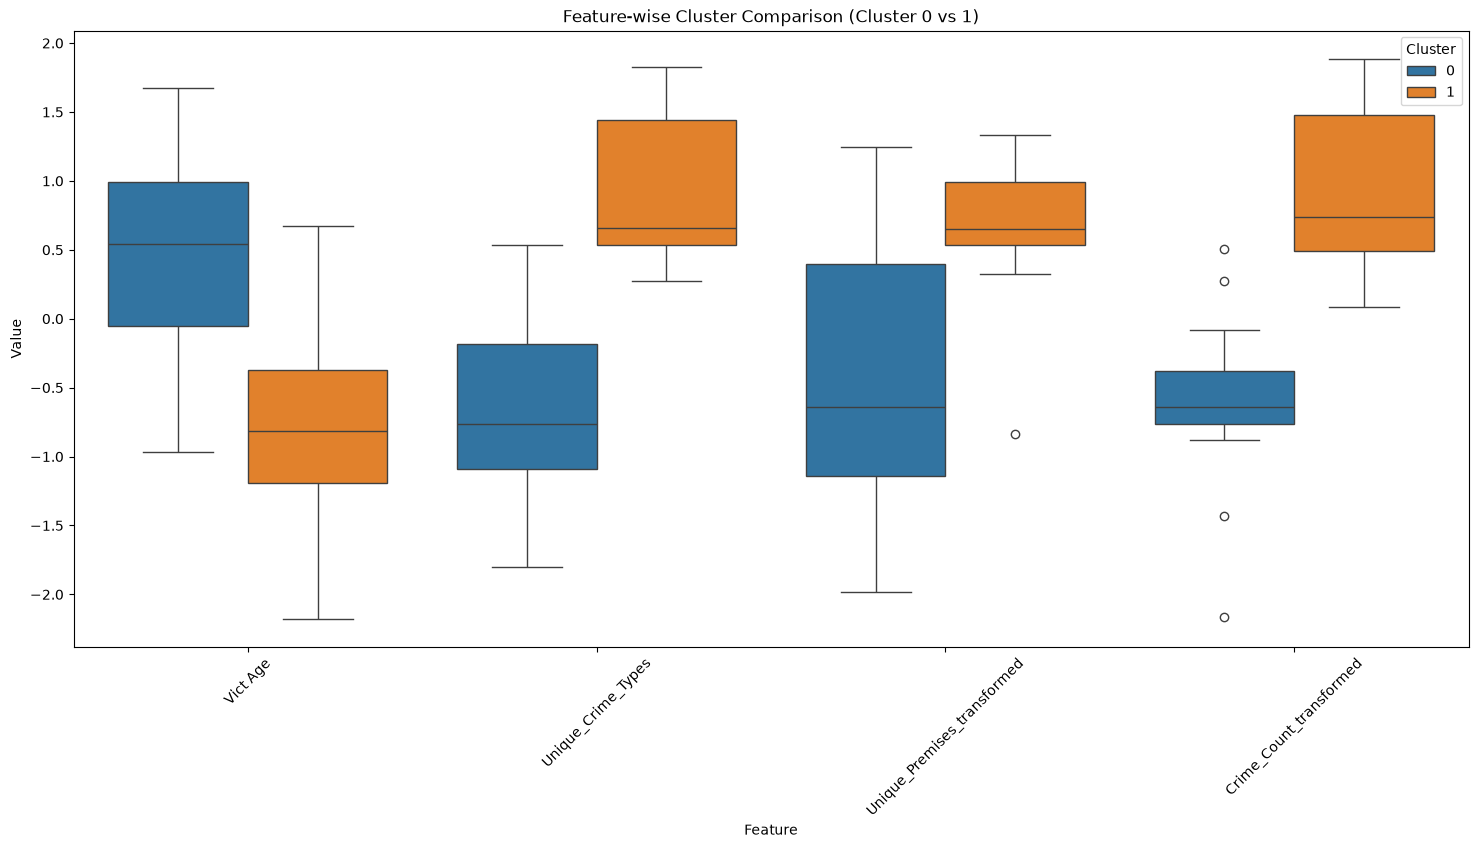

In [144]:
# remove spatial columns
df_plot = scaled_df.copy()

# convert to long format
df_long = df_plot.melt(
    id_vars="Cluster_label",
    var_name="Feature",
    value_name="Value"
)

plt.figure(figsize=(18, 8))

sns.boxplot(
    data=df_long,
    x="Feature",
    y="Value",
    hue="Cluster_label"
)

plt.title("Feature-wise Cluster Comparison (Cluster 0 vs 1)")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.show()

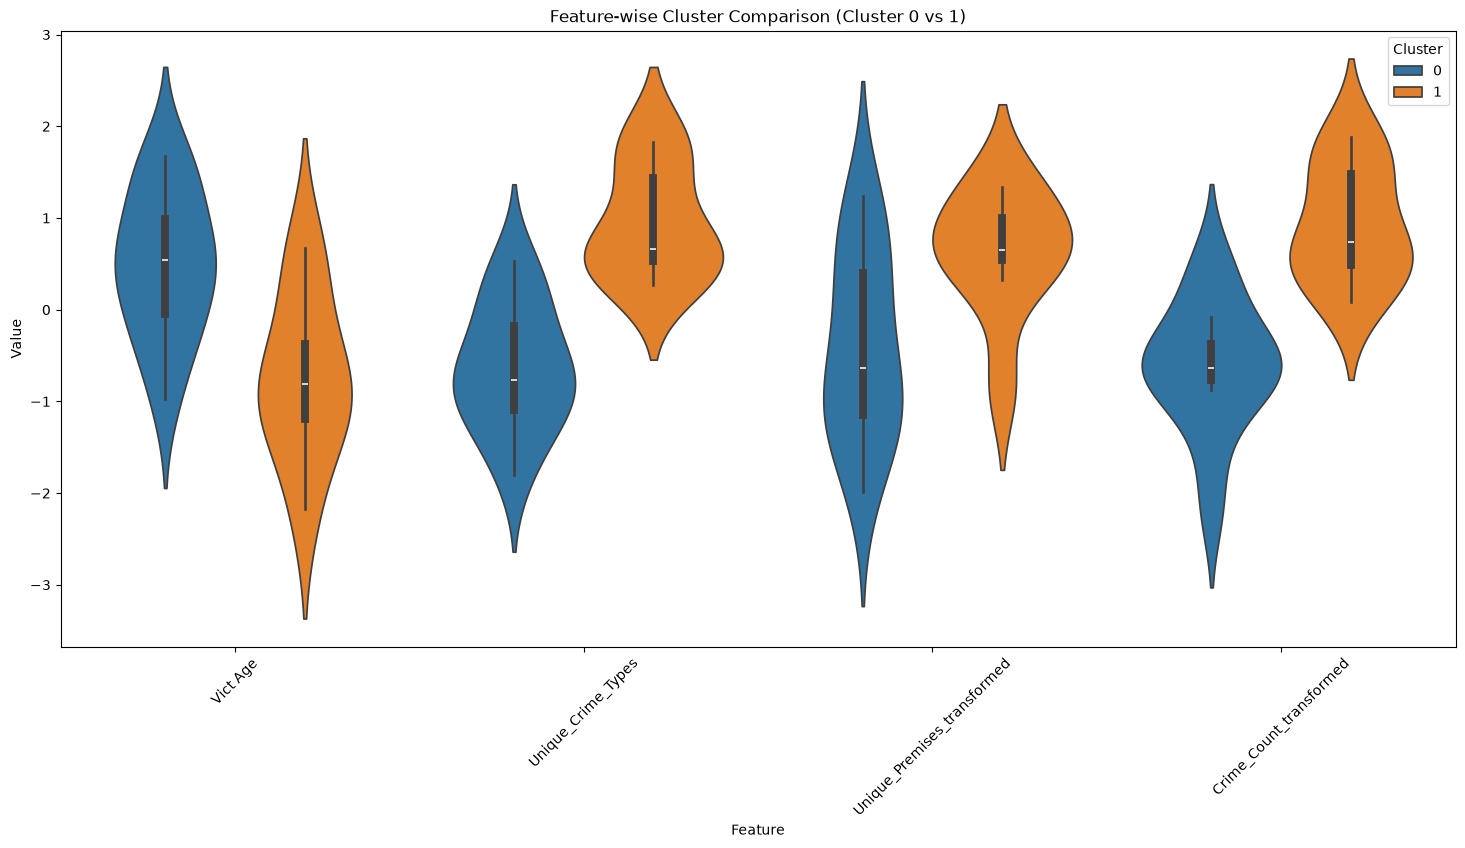

In [145]:
# remove spatial columns
df_plot = scaled_df.copy()

# convert to long format
df_long = df_plot.melt(
    id_vars="Cluster_label",
    var_name="Feature",
    value_name="Value"
)

plt.figure(figsize=(18, 8))

sns.violinplot(
    data=df_long,
    x="Feature",
    y="Value",
    hue="Cluster_label"
)

plt.title("Feature-wise Cluster Comparison (Cluster 0 vs 1)")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.show()

## Post analysis Interpretation

Cluster 0 : Moderate Crime Hotspot

Cluster 1 : High Crime Hotspot

In [148]:
outlier

,Crime_Count,Vict Age,Unique_Premises,Unique_Crime_Types,Unique_Premises_transformed,Crime_Count_transformed,Cluster_label,CLUSTER DESC
AREA NAME,,,,,,,,
Central,69599,37.938391,222,118,5.407172,11.15052,-1,MULTI-LOCATION EXTREME CRIME HOTSPOT


In [149]:
non_outlier['CLUSTER DESC']=non_outlier['Cluster_label'].map(
    {
        0 : "MODERATE CRIME HOTSPOT",
        1 : "HIGH CRIME HOTSPOT"
    }
)
non_outlier

,Crime_Count,Vict Age,Unique_Premises,Unique_Crime_Types,Unique_Premises_transformed,Crime_Count_transformed,Cluster_label,CLUSTER DESC
AREA NAME,,,,,,,,
77th Street,61695,38.481278,171,119,5.147494,11.029974,1,HIGH CRIME HOTSPOT
Devonshire,41645,42.318330,190,111,5.252273,10.636961,0,MODERATE CRIME HOTSPOT
Foothill,33094,40.274744,168,109,5.129899,10.407137,0,MODERATE CRIME HOTSPOT
Harbor,41421,40.516590,193,116,5.267858,10.631567,0,MODERATE CRIME HOTSPOT
Hollenbeck,37031,39.272606,169,111,5.135798,10.519538,0,MODERATE CRIME HOTSPOT
Hollywood,52388,37.818733,186,116,5.231109,10.866452,1,HIGH CRIME HOTSPOT
Mission,40326,38.908874,171,113,5.147494,10.604776,0,MODERATE CRIME HOTSPOT
N Hollywood,51039,40.222524,194,121,5.273000,10.840365,1,HIGH CRIME HOTSPOT
Newton,49140,37.240289,186,116,5.231109,10.802449,1,HIGH CRIME HOTSPOT


In [153]:
Final_DF = pd.concat([non_outlier , outlier])
Final_DF.to_csv("Final_clustered_dataset.csv" , index=True)

In [154]:
pd.read_csv('Final_clustered_dataset.csv')

,AREA NAME,Crime_Count,Vict Age,Unique_Premises,Unique_Crime_Types,Unique_Premises_transformed,Crime_Count_transformed,Cluster_label,CLUSTER DESC
0,77th Street,61695,38.481278,171,119,5.147494,11.029974,1,HIGH CRIME HOTSPOT
1,Devonshire,41645,42.318330,190,111,5.252273,10.636961,0,MODERATE CRIME HOTSPOT
2,Foothill,33094,40.274744,168,109,5.129899,10.407137,0,MODERATE CRIME HOTSPOT
3,Harbor,41421,40.516590,193,116,5.267858,10.631567,0,MODERATE CRIME HOTSPOT
4,Hollenbeck,37031,39.272606,169,111,5.135798,10.519538,0,MODERATE CRIME HOTSPOT
5,Hollywood,52388,37.818733,186,116,5.231109,10.866452,1,HIGH CRIME HOTSPOT
6,Mission,40326,38.908874,171,113,5.147494,10.604776,0,MODERATE CRIME HOTSPOT
7,N Hollywood,51039,40.222524,194,121,5.273000,10.840365,1,HIGH CRIME HOTSPOT
8,Newton,49140,37.240289,186,116,5.231109,10.802449,1,HIGH CRIME HOTSPOT
9,Northeast,42909,40.942865,186,107,5.231109,10.666860,0,MODERATE CRIME HOTSPOT
